# Análisis ConnectaTel

Como **analista de datos**, el objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajaremos con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users_latam.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Se explorarán, limpiarán y analizarán estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarse con la estructura de los tres datasets**.  
En esta etapa, validaremos que los archivos se carguen correctamente, conoceremos sus columnas y tipos de datos, y detectaremos posibles inconsistencias.

### 1.1 Carga de datos y vista rápida


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.


In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩 Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.


In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos en users:")
print(users.isna().sum())
print("\nProporción de valores nulos en users:")
print(users.isna().mean().round(4))

Cantidad de valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.0000
first_name    0.0000
last_name     0.0000
age           0.0000
city          0.1172
reg_date      0.0000
plan          0.0000
churn_date    0.8835
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos en usage:")
print(usage.isna().sum())
print("\nProporción de valores nulos en usage:")
print(usage.isna().mean().round(4))

Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage:
id          0.0000
user_id     0.0000
type        0.0000
date        0.0012
duration    0.5519
length      0.4474
dtype: float64


✍️ **Comentario — Diagnóstico de valores nulos:**

**Dataset `users`:**
- `city`: tiene 469 nulos (~11.7%) más 96 valores sentinel `'?'`. En total ~14.1% de filas con ciudad desconocida. Acción: reemplazar `'?'` por `pd.NA` y **dejar como nulos** (no es posible imputar ciudad con precisión).
- `churn_date`: ~88.4% de nulos. Esto es **correcto y esperado**: representa usuarios que **no han dado baja** (churn = 0). No se elimina ni imputa; se interpreta como cliente activo.

**Dataset `usage`:**
- `duration`: ~55.2% de nulos. Indica que esos registros son **mensajes de texto** (no llamadas), por lo que no tienen duración. MAR condicionado a `type`.
- `length`: ~44.8% de nulos. Indica que esos registros son **llamadas**, que no tienen longitud de mensaje. MAR condicionado a `type`.
- `date`: 50 nulos (<0.13%). Se pueden dejar como nulos o excluir en análisis temporales.

**Acción general:** Los nulos en `duration` y `length` son estructurales (MAR), no errores. Se dejan como están.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.


In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador entero secuencial que va de 10000 a 13999, sin valores fuera de rango.
- La columna `age` presenta un mínimo de **-999**, que es un valor **sentinel** (valor centinela) claramente inválido para una edad. Se detectaron **55 registros** con este valor. Acción: reemplazar por la **mediana** de los valores válidos.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son identificadores enteros sin valores fuera de rango.
- La columna `duration` tiene valores desde 0 hasta 120 minutos, lo que representa llamadas muy breves o muy largas pero no imposibles.
- La columna `length` tiene valores desde 0 hasta 1490, con una distribución sesgada a la derecha (posibles outliers en mensajes muy largos).

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- {col} ---")
    print(users[col].value_counts(dropna=False))


--- city ---
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

--- plan ---
plan
Basico     2595
Premium    1405
Name: count, dtype: int64


- La columna `city` contiene el valor `'?'` en **96 registros**, que es un sentinel para ciudad desconocida. Acción: reemplazar por `pd.NA`.
- La columna `plan` tiene solo dos valores válidos: `'Basico'` y `'Premium'`, sin inconsistencias.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

type
text    22092
call    17908
Name: count, dtype: int64

- La columna `type` contiene únicamente los valores `'text'` (22,092) y `'call'` (17,908). No hay valores inválidos ni sentinels.


---
✍️ **Comentario — Valores inválidos o sentinels detectados:**

- `age` en `users`: sentinel **-999** en 55 registros (1.4%). Acción: reemplazar con la mediana de valores válidos.
- `city` en `users`: sentinel **'?'** en 96 registros (2.4%). Acción: reemplazar con `pd.NA` (ciudad desconocida).
- No se detectaron sentinels en `usage` ni en `plans`.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.


In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

En `reg_date`, se detectan registros con año **2026** (40 registros), que es una fecha futura imposible dado que el análisis cubre hasta 2024. Estos deben marcarse como nulos. Los años 2022, 2023 y 2024 son válidos.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

date
2024.0    39950
Name: count, dtype: int64

En `date` (usage), todos los registros con fecha corresponden al año **2024**, que es el año de análisis esperado. No hay fechas fuera de rango en este dataset.  
Basaremos el análisis en estas fechas.


✍️ **Comentario — Fechas fuera de rango:**

- En `reg_date` se detectaron **40 registros con año 2026**, que es una fecha futura e imposible dentro del contexto del análisis (datos hasta 2024). Acción: marcar como `pd.NaT`.
- En `date` (usage) no se detectaron fechas fuera de rango; todos los registros caen en 2024.

---

## 🧩 Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles


In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores únicos en city (top 10):")
print(users['city'].value_counts(dropna=False).head(10))

Valores únicos en city (top 10):
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
<NA>         96
Name: count, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Años presentes en reg_date después de limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"\nFechas nulas: {users['reg_date'].isna().sum()}")

Años presentes en reg_date después de limpieza:
reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64

Fechas nulas: 40


### 3.2 Verificación MAR en columnas de uso

**🎯 Objetivo:**  
Verificar si los nulos en `duration` y `length` son **MAR** (Missing At Random) revisando si dependen del tipo de evento (`type`).


In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en 'duration' por tipo de evento:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

Nulos en 'duration' por tipo de evento:
type
call        0
text    22076
Name: duration, dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print("Nulos en 'length' por tipo de evento:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))

Nulos en 'length' por tipo de evento:
type
call    17896
text        0
Name: length, dtype: int64


✍️ **Diagnóstico de nulos en `duration` y `length`:**

- **`duration`**: todos los nulos (22,076) corresponden a eventos de tipo `'text'`. Las llamadas (`call`) no tienen ningún nulo. Esto confirma que los nulos son **MAR condicionado a `type`**: los mensajes no tienen duración, por lo que el nulo es **estructuralmente correcto**. Acción: dejar como nulos.
- **`length`**: todos los nulos (17,896) corresponden a eventos de tipo `'call'`. Los mensajes (`text`) no tienen ningún nulo. Mismo razonamiento: las llamadas no tienen longitud de mensaje. Acción: dejar como nulos.

Ambas columnas son complementarias: una aplica para texto y la otra para llamadas.

---

## 🧩 Paso 4: Summary statistics de uso por usuario

### 4.1 Agrupación por comportamiento de uso

🎯 **Objetivo:** Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.


In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Las columnas ya fueron nombradas directamente en .agg(), no es necesario renombrar
# Verificamos que los nombres sean correctos
print("Columnas de usage_agg:", usage_agg.columns.tolist())

# observar resultado
usage_agg.head(3)

Columnas de usage_agg: ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios para identificar rangos, valores extremos y distribución de los datos.


In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).mul(100).round(1).rename('porcentaje (%)')

plan
Basico     64.9
Premium    35.1
Name: porcentaje (%), dtype: float64

---

## 🧩 Paso 5: Visualización de distribuciones (uso y clientes) y outliers

### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave de **uso** y **clientes**, y observar si existen diferencias según el tipo de plan.


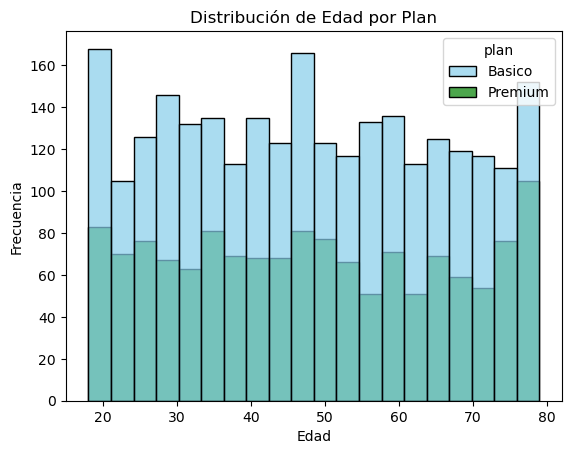

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=20,
             palette=['skyblue', 'green'], alpha=0.7)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡 **Insights:**
- **Distribución:** Aproximadamente uniforme entre 18 y 79 años, con ligero sesgo hacia edades medias.
- Tanto el plan Básico como el Premium tienen una distribución de edades similar; no se observa una concentración notable de un plan en un rango de edad específico.
- El plan Básico tiene más usuarios en todos los rangos, lo que refleja su mayor volumen total (65% vs 35%).

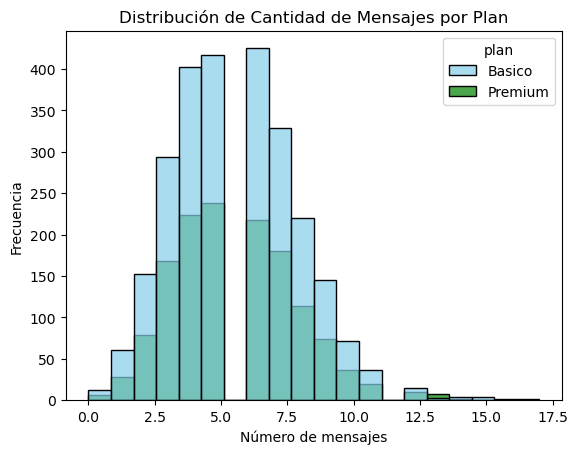

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=20,
             palette=['skyblue', 'green'], alpha=0.7)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Número de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡 **Insights:**
- **Distribución:** Sesgada a la derecha. La mayoría de usuarios envía entre 3 y 8 mensajes, con una cola de usuarios con volúmenes elevados.
- Los usuarios Premium tienden a enviar ligeramente más mensajes, lo que es consistente con tener un límite de mensajes incluidos más alto en su plan (500 vs 100).

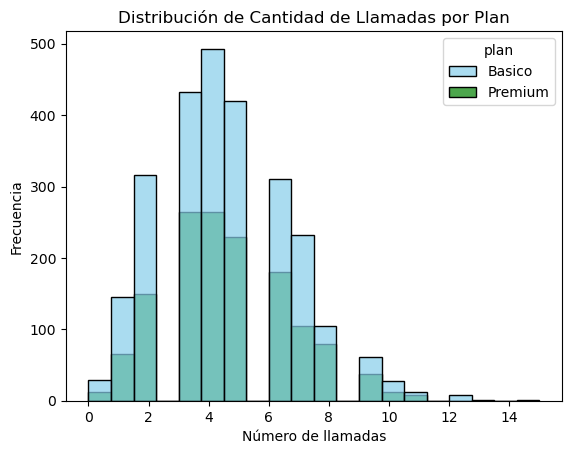

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=20,
             palette=['skyblue', 'green'], alpha=0.7)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Número de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡 **Insights:**
- **Distribución:** Sesgada a la derecha. La mayoría de usuarios realiza entre 2 y 7 llamadas, con pocos usuarios en los extremos altos.
- Ambos planes tienen comportamientos similares en llamadas; sin diferencias marcadas por plan.

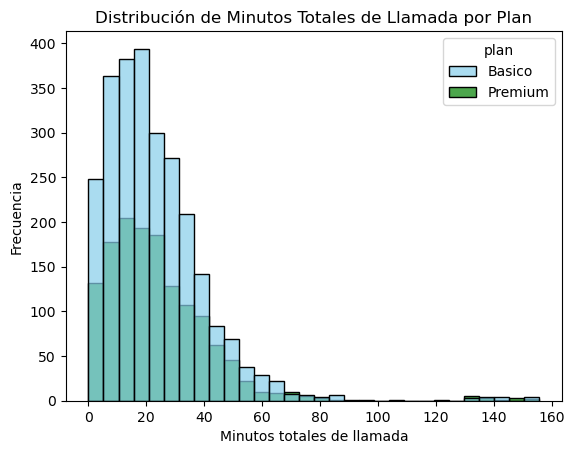

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=30,
             palette=['skyblue', 'green'], alpha=0.7)
plt.title('Distribución de Minutos Totales de Llamada por Plan')
plt.xlabel('Minutos totales de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡 **Insights:**
- **Distribución:** Claramente sesgada a la derecha. La mayoría concentra entre 0 y 40 minutos, con una cola larga hacia 150+ minutos.
- Se observan outliers evidentes en la cola derecha. El plan Premium presenta algunos usuarios con consumo de minutos especialmente alto, lo que podría indicar aprovechamiento intensivo del plan o comportamientos atípicos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis.


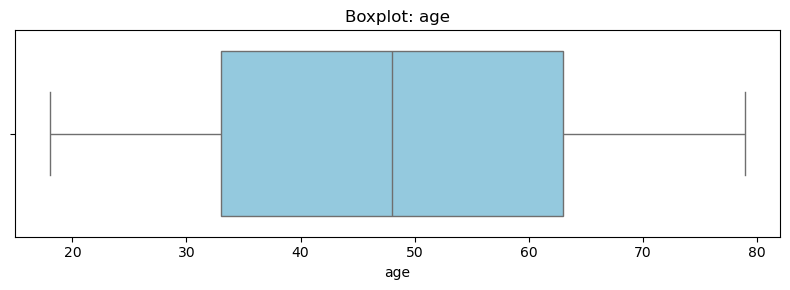

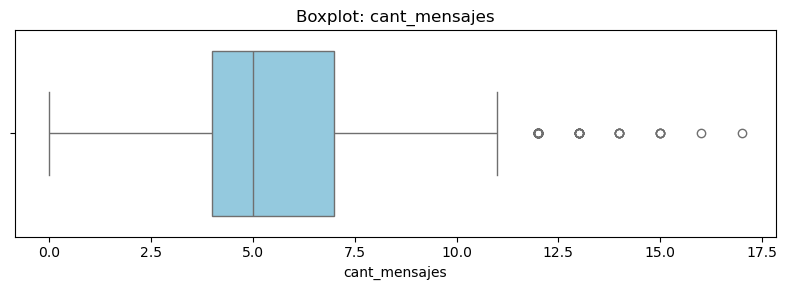

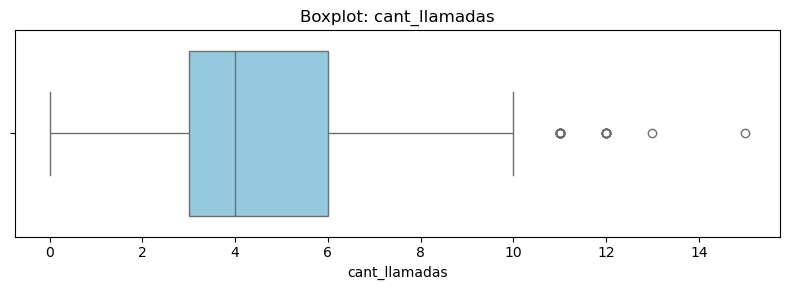

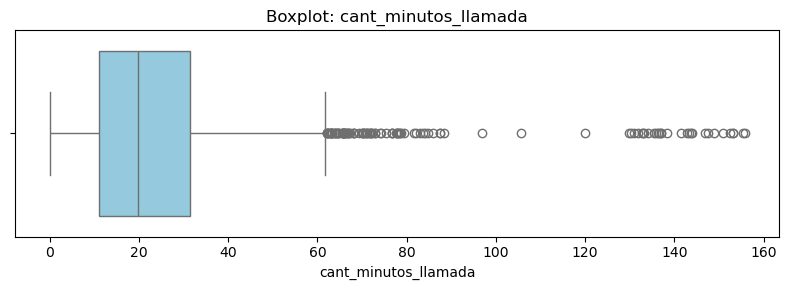

In [34]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()

💡 **Insights:**
- **age:** No presenta outliers. La distribución es uniforme entre 18 y 79 años.
- **cant_mensajes:** Sí presenta outliers en la parte superior (usuarios con más de ~11 mensajes).
- **cant_llamadas:** Sí presenta outliers en la parte superior (usuarios con más de ~10 llamadas).
- **cant_minutos_llamada:** Sí presenta outliers marcados en la parte superior (usuarios con más de ~62 minutos totales).

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    n_outliers = (user_profile[col] > limite_superior).sum()
    print(f"{col}: Q1={Q1}, Q3={Q3}, IQR={IQR:.2f}, "
          f"límite superior={limite_superior:.2f}, "
          f"max={user_profile[col].max()}, outliers={n_outliers}")

cant_mensajes: Q1=4.0, Q3=7.0, IQR=3.00, límite superior=11.50, max=17.0, outliers=46
cant_llamadas: Q1=3.0, Q3=6.0, IQR=3.00, límite superior=10.50, max=15.0, outliers=30
cant_minutos_llamada: Q1=11.12, Q3=31.415, IQR=20.30, límite superior=61.86, max=155.69, outliers=109


In [36]:
# Revisar los límites superiores y el max para tomar la decisión de mantener o no los outliers
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡 **Insights — Decisión sobre outliers:**

- **cant_mensajes:** Límite superior ≈ 11.5, máximo = 17. Los outliers representan usuarios que envían más mensajes de lo usual, pero son valores posibles en comportamiento real. Se decide **mantener** los outliers, ya que el exceso es moderado y puede representar segmentos de alto engagement.

- **cant_llamadas:** Límite superior ≈ 10.5, máximo = 15. Similar al caso anterior: posibles usuarios intensivos. Se decide **mantener** los outliers, ya que no representan valores imposibles.

- **cant_minutos_llamada:** Límite superior ≈ 61.9 minutos, máximo = 155.69 minutos. Los outliers son más pronunciados y representan usuarios con llamadas muy largas. Se decide **mantener** los outliers para segmentación de clientes de alto consumo, ya que pueden ser casos de uso legítimo (ej. llamadas de trabajo extensas).

---

## 🧩 Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso basándose en la cantidad de llamadas y mensajes registrados.


In [37]:
# Crear columna grupo_uso usando np.select
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:** Clasificar a cada usuario en un grupo por **edad**.


In [39]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 'Joven',
    np.where(user_profile['age'] < 60, 'Adulto', 'Adulto Mayor')
)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.


/var/folders/d8/bfkz4xj57x9461j_m02n4ddm0000gn/T/ipykernel_5841/3289123139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso',


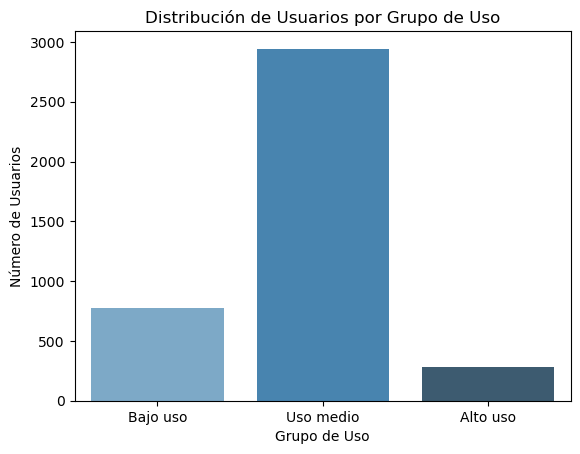

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',
              order=['Bajo uso', 'Uso medio', 'Alto uso'],
              palette='Blues_d')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Número de Usuarios')
plt.show()

/var/folders/d8/bfkz4xj57x9461j_m02n4ddm0000gn/T/ipykernel_5841/478541476.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad',


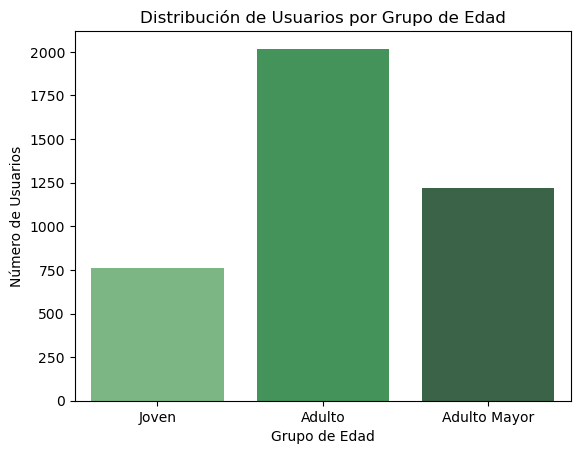

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',
              order=['Joven', 'Adulto', 'Adulto Mayor'],
              palette='Greens_d')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de Usuarios')
plt.show()

---
## 🧩 Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio.


### Análisis ejecutivo

---

⚠️ **Problemas detectados en los datos**

- **`age` (sentinel -999):** Se detectaron **55 registros** (1.4% del total) con edad igual a -999, un valor claramente inválido. Fueron reemplazados por la mediana de los valores válidos (47 años).
- **`city` (sentinel '?'):** **96 registros** (2.4%) tenían la ciudad capturada como `'?'`. Junto con los 469 nulos reales, un 14.1% de usuarios no tiene ciudad registrada. Estos valores fueron convertidos a nulo.
- **`reg_date` (fechas futuras):** **40 registros** (1.0%) tenían fecha de registro en 2026, año que excede el rango de análisis (hasta 2024). Fueron marcados como nulos.
- **`duration` y `length` (nulos estructurales):** Los ~55% de nulos en `duration` y ~45% en `length` no son errores: corresponden a mensajes de texto y llamadas respectivamente, que por naturaleza no tienen ese campo. Son MAR condicionados al tipo de evento y se dejaron como nulos correctamente.

---

🔍 **Segmentos por Edad**

- **Adultos (30–59 años):** Segmento más numeroso con ~2,018 usuarios (50.5%). Es el grupo dominante y diverso en comportamiento.
- **Adultos Mayores (60+ años):** ~1,222 usuarios (30.6%). Representan un tercio de la base; pueden tener menor afinidad digital y requerir planes simples con soporte diferenciado.
- **Jóvenes (<30 años):** ~760 usuarios (19.0%). El segmento más pequeño pero potencialmente el más rentable a largo plazo, con mayor probabilidad de uso intensivo de datos y mensajería.

---

📊 **Segmentos por Nivel de Uso**

- **Uso Medio (~73.6%):** La gran mayoría de clientes (2,943) tiene un consumo moderado entre 5–9 llamadas y mensajes. Son el segmento ancla del negocio.
- **Bajo Uso (~19.5%):** 778 usuarios con menos de 5 llamadas y mensajes. Podrían estar infrautilizando su plan o usar ConnectaTel como línea secundaria.
- **Alto Uso (~7.0%):** 279 usuarios con 10+ llamadas y mensajes. Son el segmento de mayor valor y mayor riesgo de excederse del plan (especialmente usuarios Básico).

---

➡️ Esto sugiere que **la mayoría de la base es de consumo moderado**, con un segmento de alto uso relativamente pequeño pero estratégico. Los usuarios de alto uso en plan Básico son candidatos claros para migración a Premium. Los de bajo uso podrían ser objetivo de campañas de activación o planes más económicos.

---

💡 **Recomendaciones**

1. **Campaña de upsell para alto uso en plan Básico:** Identificar usuarios con `grupo_uso = 'Alto uso'` y `plan = 'Basico'` para ofrecerles migración proactiva al plan Premium, antes de que incurran en cargos extra y generen churn.
2. **Plan lite para usuarios de bajo uso:** Crear un plan de entrada más económico (menos minutos/mensajes, menor costo mensual) para retener a los ~778 usuarios de bajo uso que podrían cancelar por percibir el plan como caro para su nivel de consumo.
3. **Atención diferenciada por edad:** Diseñar comunicación y soporte específico para Adultos Mayores (60+), que representan ~30% de la base y pueden tener menor adopción digital.
4. **Estrategia de captación de jóvenes:** Con solo 19% de usuarios jóvenes, existe oportunidad de crecer en este segmento con planes digitales, mayor datos incluidos y precios competitivos.
5. **Investigar outliers de alto consumo de minutos:** Los ~usuarios con 100+ minutos pueden ser candidatos a planes de llamadas ilimitadas o paquetes de voz especiales, aumentando su ticket promedio sin riesgo de churn.

---

## 🧩 Paso 8: Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.

### Opción A: Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis`).
3. Sube tu notebook con **Add file → Upload files**.

---

### Opción B: Guardar directo desde Google Colab

1. Abre tu notebook en Colab.
2. Ve a **File → Save a copy in GitHub**.
3. Selecciona el repositorio y la carpeta correcta.
4. Escribe un mensaje de commit claro: `feat: add final ConnectaTel analysis`.
5. Verifica en GitHub que el archivo quedó en el lugar correcto.

---

Agrega un archivo `README.md` que describa:
- El objetivo del proyecto.
- Los datasets utilizados.
- Las etapas del análisis realizadas.
- Cómo ejecutar el notebook.
- Una breve guía de reproducción.

Link a repositorio público del proyecto: `LINK a tu repo aquí`